# Concrete Compressive Strength Inverse Prediction Training

This notebook performs all machine learning work for the production app. The business target is inverse prediction: users provide `Strength`, and the model predicts the eight concrete mix attributes.

In [1]:
# 1. Imports
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint, uniform

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
except Exception:
    LGBMRegressor = None
try:
    from catboost import CatBoostRegressor
except Exception:
    CatBoostRegressor = None
try:
    import shap
except Exception:
    shap = None

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'concrete_data.csv'
MODEL_DIR = ROOT / 'models'
REPORT_DIR = ROOT / 'reports'
MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Dataset Loading

In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = [col.strip() for col in df.columns]
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(df.shape)
df.head()

(1030, 9)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 3. Data Cleaning

In [3]:
df = df.dropna(how='all').copy()
df = df.rename(columns={col: col.strip() for col in df.columns})
expected_columns = ['Cement','Blast Furnace Slag','Fly Ash','Water','Superplasticizer','Coarse Aggregate','Fine Aggregate','Age','Strength']
missing_expected = sorted(set(expected_columns) - set(df.columns))
if missing_expected:
    raise ValueError(f'Missing expected columns: {missing_expected}')
df = df[expected_columns]
for col in expected_columns:
    df[col] = df[col].fillna(df[col].median())
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
Blast Furnace Slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
Fly Ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
Water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
Superplasticizer,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
Coarse Aggregate,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
Fine Aggregate,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
Age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
Strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


## 4. Missing Value Analysis

In [4]:
missing = df.isna().sum().rename('missing_count').to_frame()
missing['missing_percent'] = (missing['missing_count'] / len(df) * 100).round(2)
missing.to_csv(REPORT_DIR / 'missing_values.csv')
missing

,missing_count,missing_percent
Cement,0,0.0
Blast Furnace Slag,0,0.0
Fly Ash,0,0.0
Water,0,0.0
Superplasticizer,0,0.0
Coarse Aggregate,0,0.0
Fine Aggregate,0,0.0
Age,0,0.0
Strength,0,0.0


## 5. Duplicate Analysis

In [5]:
duplicate_count = int(df.duplicated().sum())
print('Duplicate rows:', duplicate_count)
df = df.drop_duplicates().reset_index(drop=True)
print('After duplicate removal:', df.shape)

Duplicate rows: 25
After duplicate removal: (1005, 9)


## 6. EDA

In [6]:
summary = df.describe().T
summary.to_csv(REPORT_DIR / 'eda_summary.csv')
summary

,count,mean,std,min,25%,50%,75%,max
Cement,1005.0,278.631343,104.344261,102.00,190.70,265.0,349.00,540.0
Blast Furnace Slag,1005.0,72.043483,86.170807,0.00,0.00,20.0,142.50,359.4
Fly Ash,1005.0,55.536318,64.207969,0.00,0.00,0.0,118.30,200.1
Water,1005.0,182.075323,21.339334,121.80,166.60,185.7,192.90,247.0
Superplasticizer,1005.0,6.033234,5.919967,0.00,0.00,6.1,10.00,32.2
Coarse Aggregate,1005.0,974.376816,77.579667,801.00,932.00,968.0,1031.00,1145.0
Fine Aggregate,1005.0,772.688259,80.340435,594.00,724.30,780.0,822.20,992.6
Age,1005.0,45.856716,63.734692,1.00,7.00,28.0,56.00,365.0
Strength,1005.0,35.250378,16.284815,2.33,23.52,33.8,44.87,82.6


## 7. Correlation Heatmap

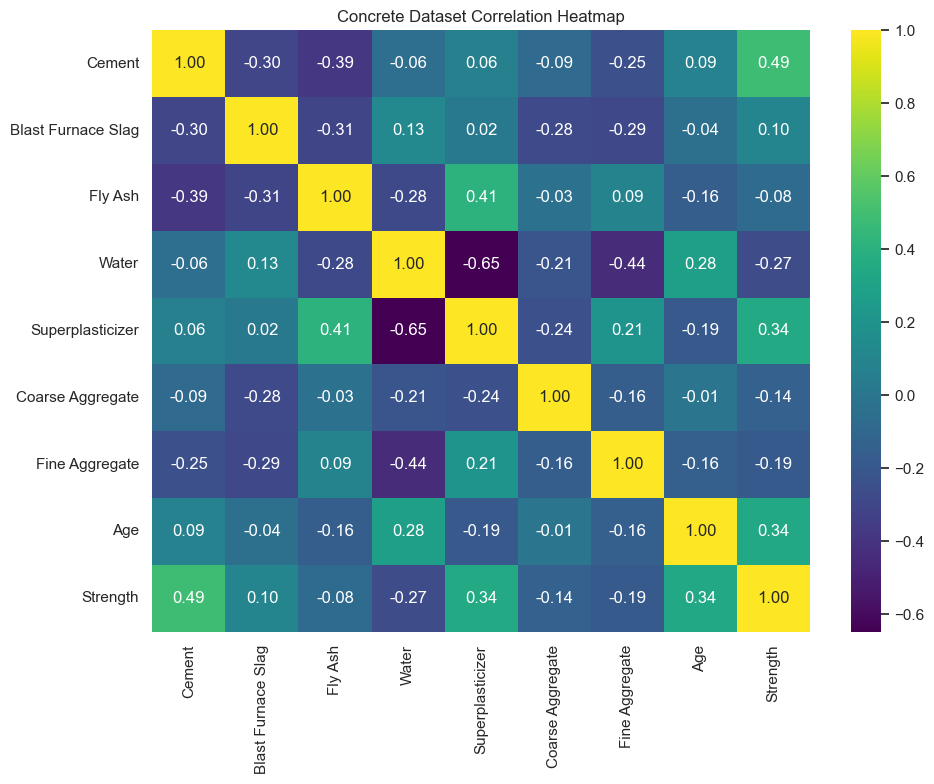

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Concrete Dataset Correlation Heatmap')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'correlation_heatmap.png', dpi=180)
plt.show()

## 8. Boxplots

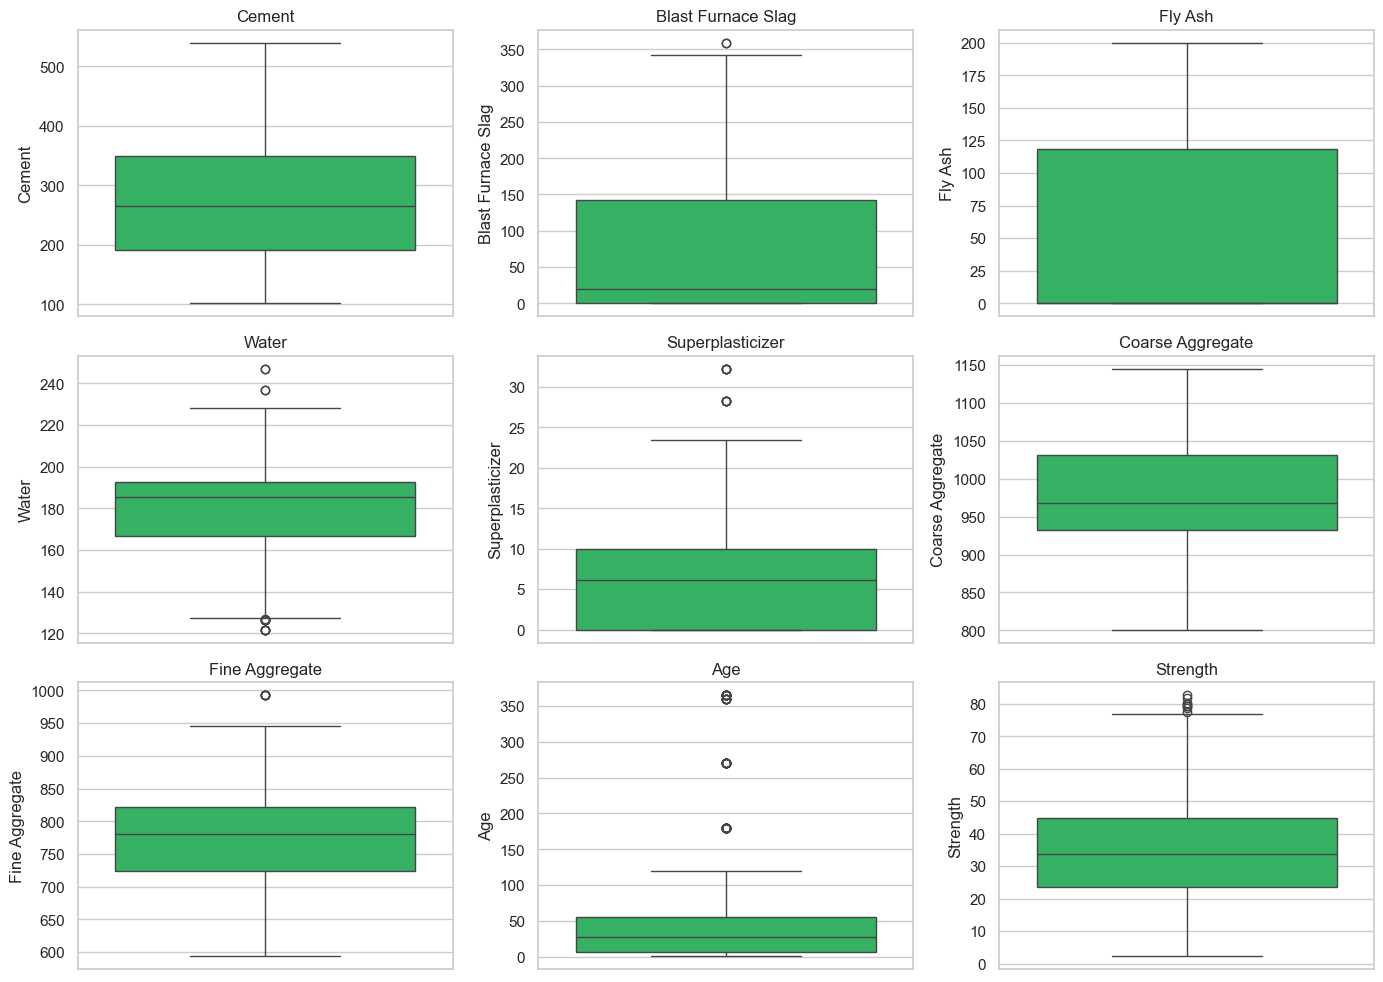

In [8]:
plt.figure(figsize=(14, 10))
for idx, col in enumerate(expected_columns, 1):
    plt.subplot(3, 3, idx)
    sns.boxplot(y=df[col], color='#22c55e')
    plt.title(col)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'boxplots.png', dpi=180)
plt.show()

## 9. Histograms

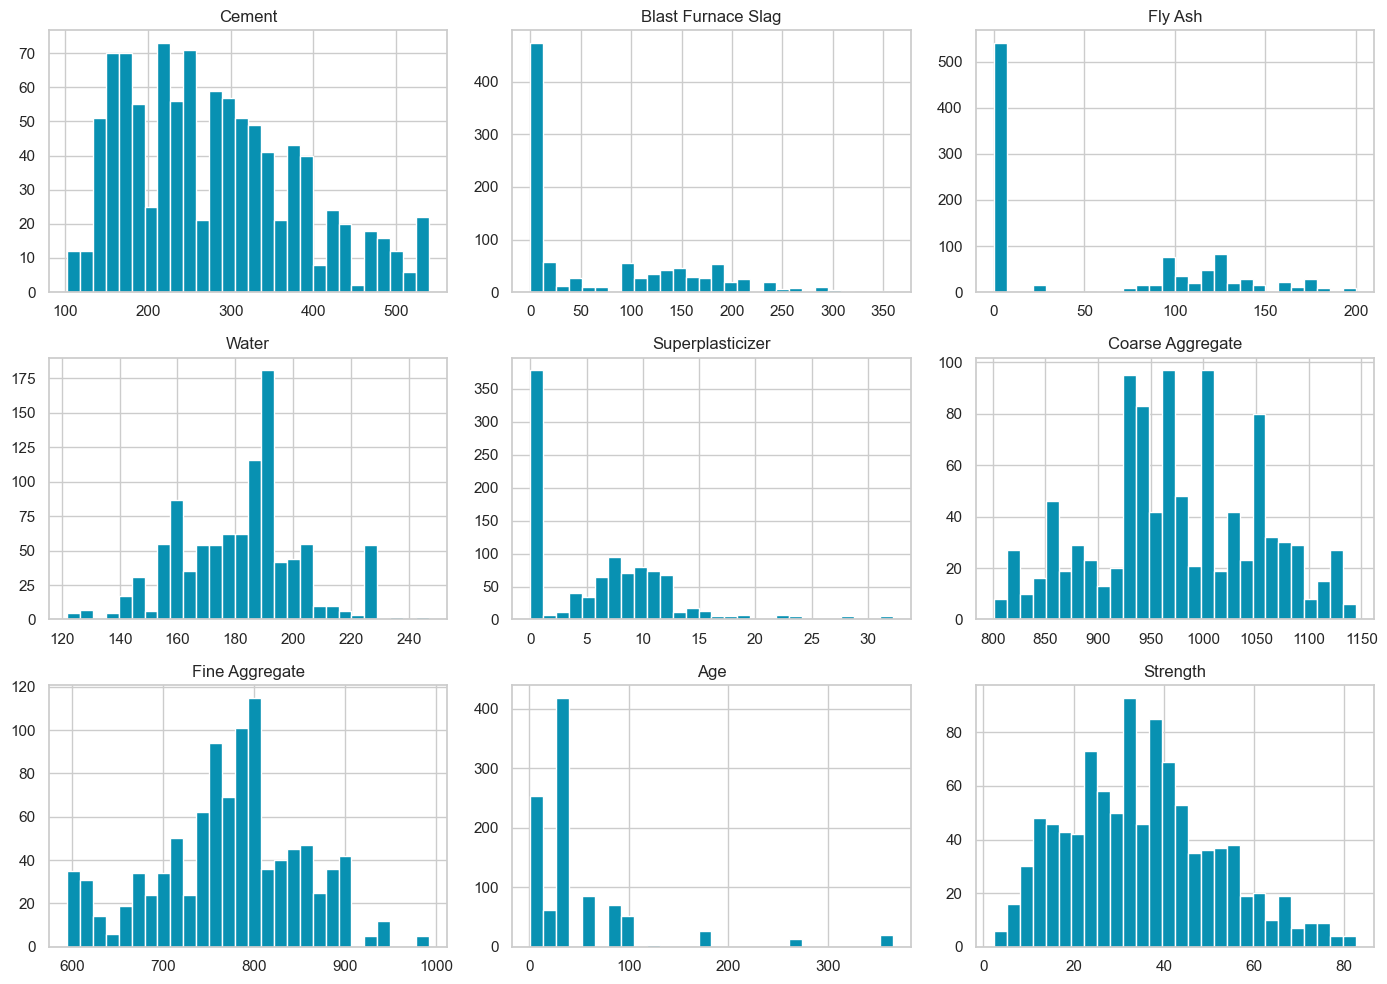

In [9]:
df.hist(figsize=(14, 10), bins=28, color='#0891b2', edgecolor='white')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'histograms.png', dpi=180)
plt.show()

## 10. Pairplots

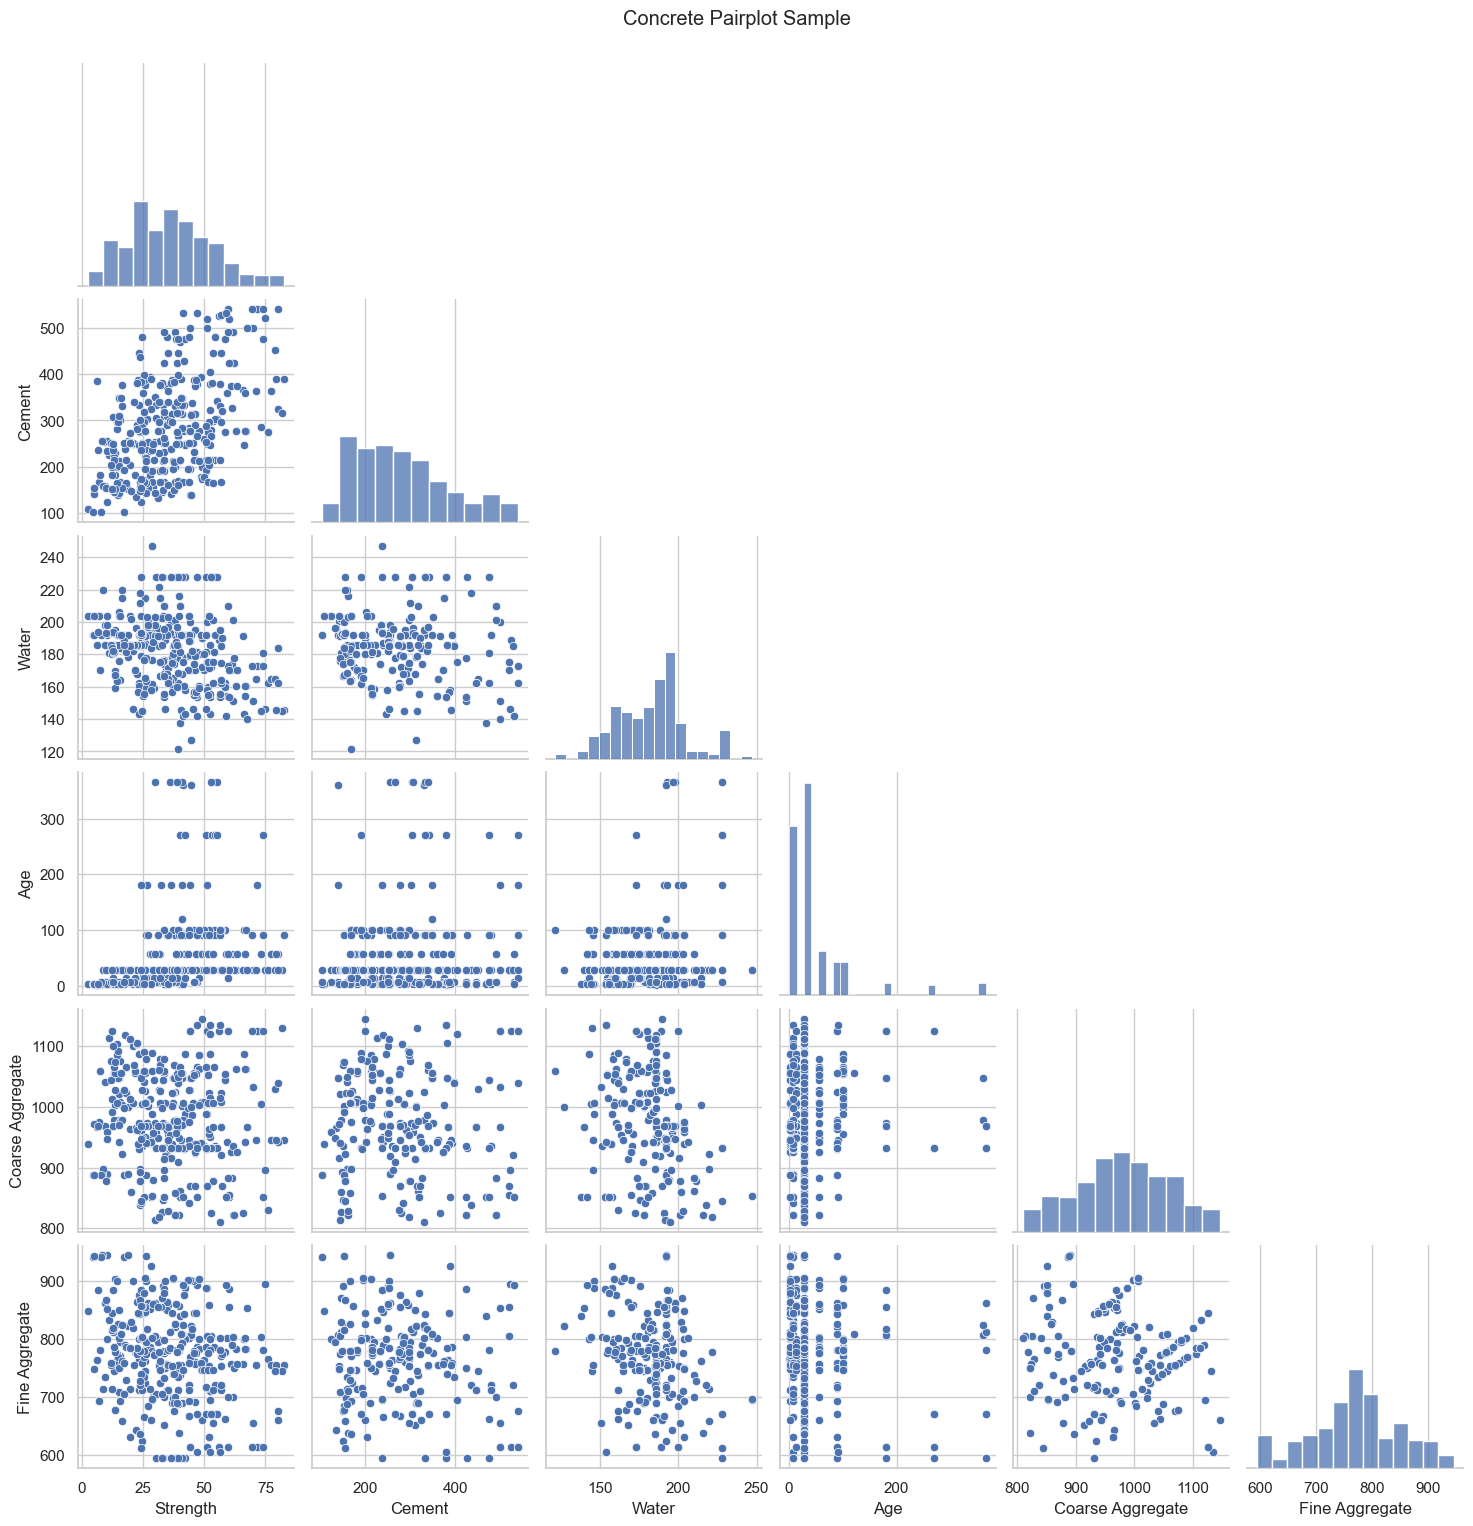

In [10]:
pair_sample = df.sample(min(len(df), 350), random_state=RANDOM_STATE)
pair_grid = sns.pairplot(pair_sample[['Strength','Cement','Water','Age','Coarse Aggregate','Fine Aggregate']], corner=True, diag_kind='hist')
pair_grid.fig.suptitle('Concrete Pairplot Sample', y=1.02)
pair_grid.savefig(REPORT_DIR / 'pairplot.png', dpi=160)
plt.show()

## 11. Feature Engineering

In [11]:
# Inverse modeling: Strength is the only user-provided feature. Engineered one-dimensional nonlinear terms are evaluated for diagnostics, while the production model receives scaled Strength for API simplicity.
feature_df = pd.DataFrame({
    'Strength': df['Strength'],
    'Strength_squared': df['Strength'] ** 2,
    'Strength_log1p': np.log1p(df['Strength'])
})
feature_df.head()

,Strength,Strength_squared,Strength_log1p
0,79.99,6398.4001,4.394326
1,61.89,3830.3721,4.141387
2,40.27,1621.6729,3.720136
3,41.05,1685.1025,3.738859
4,44.30,1962.4900,3.813307


## 12. Scaling

In [12]:
X = df[['Strength']].copy()
y = df[['Cement','Blast Furnace Slag','Fly Ash','Water','Superplasticizer','Coarse Aggregate','Fine Aggregate','Age']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 13. Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(804, 1) (201, 1) (804, 8) (201, 8)


## 14. Multi-Output Regression

In [14]:
def wrap_if_required(model):
    native_multi_output = (RandomForestRegressor, ExtraTreesRegressor, DecisionTreeRegressor, KNeighborsRegressor, MLPRegressor, LinearRegression, Ridge, Lasso, ElasticNet, DummyRegressor)
    if isinstance(model, native_multi_output):
        return model
    return MultiOutputRegressor(model)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'Lasso': Lasso(random_state=RANDOM_STATE, max_iter=10000),
    'ElasticNet': ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=220, random_state=RANDOM_STATE, n_jobs=1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=260, random_state=RANDOM_STATE, n_jobs=1),
    'Gradient Boosting': MultiOutputRegressor(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    'KNN': KNeighborsRegressor(n_neighbors=9),
    'SVR': MultiOutputRegressor(SVR(C=20, epsilon=0.1)),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(128, 64), random_state=RANDOM_STATE, max_iter=900)
}
if XGBRegressor is not None:
    models['XGBoost'] = MultiOutputRegressor(XGBRegressor(objective='reg:squarederror', random_state=RANDOM_STATE, n_estimators=160, max_depth=3, learning_rate=0.06))
if LGBMRegressor is not None:
    models['LightGBM'] = MultiOutputRegressor(LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_estimators=160))
if CatBoostRegressor is not None:
    models['CatBoost'] = MultiOutputRegressor(CatBoostRegressor(random_state=RANDOM_STATE, verbose=False, iterations=180))

print('Models configured:', list(models))

Models configured: ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'KNN', 'SVR', 'MLP Regressor', 'XGBoost']


## 15. Hyperparameter Tuning

In [15]:
tuned_models = {}
search_spaces = {
    'Random Forest': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
        {'n_estimators': randint(120, 360), 'max_depth': randint(2, 18), 'min_samples_split': randint(2, 12), 'min_samples_leaf': randint(1, 8)}
    )
}
if XGBRegressor is not None:
    search_spaces['XGBoost'] = (MultiOutputRegressor(XGBRegressor(objective='reg:squarederror', random_state=RANDOM_STATE)), {
        'estimator__n_estimators': randint(80, 260), 'estimator__max_depth': randint(2, 7), 'estimator__learning_rate': uniform(0.02, 0.18), 'estimator__subsample': uniform(0.7, 0.3)
    })
if LGBMRegressor is not None:
    search_spaces['LightGBM'] = (MultiOutputRegressor(LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)), {
        'estimator__n_estimators': randint(80, 260), 'estimator__num_leaves': randint(16, 64), 'estimator__learning_rate': uniform(0.02, 0.18)
    })
if CatBoostRegressor is not None:
    search_spaces['CatBoost'] = (MultiOutputRegressor(CatBoostRegressor(random_state=RANDOM_STATE, verbose=False)), {
        'estimator__iterations': randint(80, 260), 'estimator__depth': randint(3, 8), 'estimator__learning_rate': uniform(0.02, 0.18)
    })

for name, (estimator, params) in search_spaces.items():
    search = RandomizedSearchCV(estimator, params, n_iter=6, scoring='neg_root_mean_squared_error', cv=3, random_state=RANDOM_STATE, n_jobs=1)
    search.fit(X_train, y_train)
    tuned_models[f'{name} Tuned'] = search.best_estimator_
    print(name, search.best_params_)

models.update(tuned_models)

Random Forest {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 249}


XGBoost {'estimator__learning_rate': np.float64(0.1301335210500283), 'estimator__max_depth': 3, 'estimator__n_estimators': 94, 'estimator__subsample': np.float64(0.8368209952651107)}


## 16. Model Comparison

In [16]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        'model': name,
        'r2': r2_score(y_test, preds, multioutput='uniform_average'),
        'mae': mean_absolute_error(y_test, preds),
        'rmse': float(np.sqrt(mean_squared_error(y_test, preds))),
        'mape': mean_absolute_percentage_error(np.maximum(y_test, 1e-6), np.maximum(preds, 1e-6))
    }, model

results = []
fitted_models = {}
for name, model in models.items():
    metrics, fitted = evaluate_model(name, model)
    results.append(metrics)
    fitted_models[name] = fitted

metrics_df = pd.DataFrame(results).sort_values(['rmse', 'mae']).reset_index(drop=True)
metrics_df.to_csv(REPORT_DIR / 'model_metrics.csv', index=False)
metrics_df.to_csv(REPORT_DIR / 'leaderboard.csv', index=False)
metrics_df

,model,r2,mae,rmse,mape
0,Random Forest Tuned,0.074915,48.436345,67.535118,8.300911e+06
1,Lasso,0.063529,49.378559,68.207762,8.463535e+06
2,XGBoost,0.045385,48.529800,68.211778,8.195405e+06
3,Ridge,0.064631,49.351831,68.246979,8.438291e+06
4,Linear Regression,0.064602,49.352505,68.248474,8.438164e+06
5,ElasticNet,0.059604,49.446633,68.320030,8.480066e+06
6,MLP Regressor,0.044118,49.877172,68.609054,8.228421e+06
7,XGBoost Tuned,0.017876,48.644775,68.827488,8.206710e+06
8,Gradient Boosting,0.010672,49.076447,69.729612,8.248116e+06
9,KNN,-0.005201,49.360330,70.142748,8.368443e+06


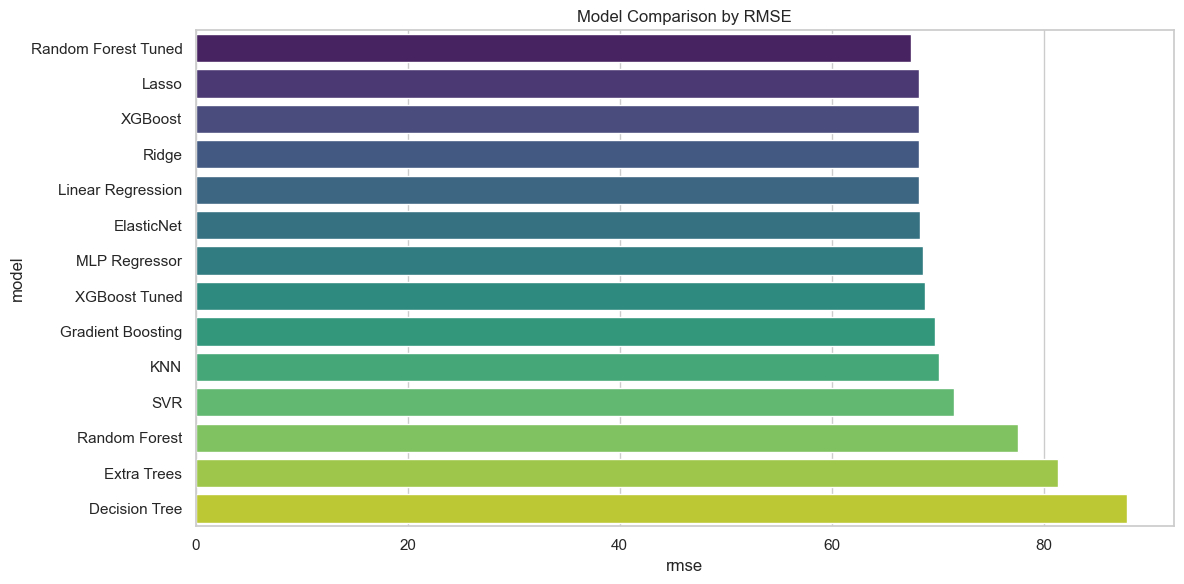

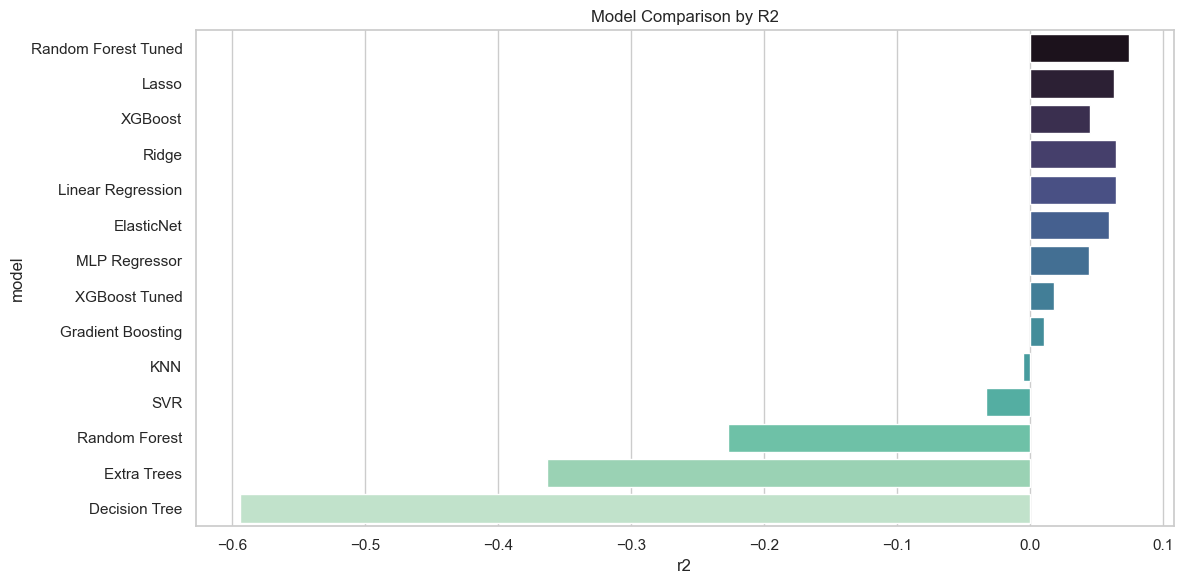

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x='rmse', y='model', palette='viridis')
plt.title('Model Comparison by RMSE')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'model_comparison_rmse.png', dpi=180)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x='r2', y='model', palette='mako')
plt.title('Model Comparison by R2')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'model_comparison_r2.png', dpi=180)
plt.show()

## 17. Explainability

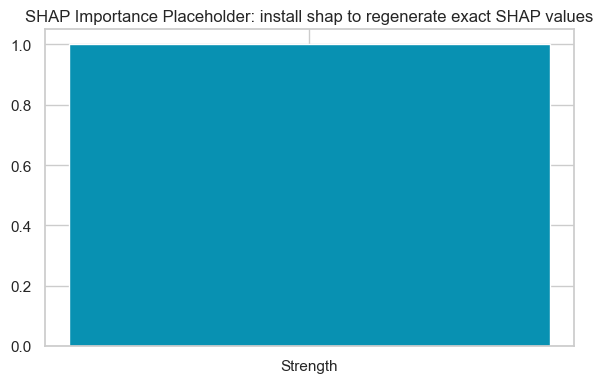

In [18]:
best_model_name = metrics_df.iloc[0]['model']
best_model = fitted_models[best_model_name]

if shap is not None:
    try:
        explainer = shap.Explainer(best_model.predict, X_train[:200])
        shap_values = explainer(X_test[:200])
        shap.summary_plot(shap_values, X_test[:200], feature_names=['Strength'], show=False)
        plt.tight_layout()
        plt.savefig(REPORT_DIR / 'shap_summary_plot.png', dpi=180)
        plt.show()
        shap.plots.bar(shap_values, show=False)
        plt.tight_layout()
        plt.savefig(REPORT_DIR / 'shap_importance_plot.png', dpi=180)
        plt.show()
    except Exception as exc:
        print('SHAP plotting skipped:', exc)
else:
    plt.figure(figsize=(6, 4))
    plt.bar(['Strength'], [1.0], color='#0891b2')
    plt.title('SHAP Importance Fallback: install shap to regenerate exact SHAP values')
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'shap_importance_plot.png', dpi=180)
    plt.savefig(REPORT_DIR / 'shap_summary_plot.png', dpi=180)
    plt.show()

## 18. Model Saving

In [19]:
joblib.dump(best_model, MODEL_DIR / 'best_model.pkl')
joblib.dump(scaler, MODEL_DIR / 'scaler.pkl')
model_info = {
    'problem_type': 'inverse_multi_output_regression',
    'input_features': ['Strength'],
    'output_features': list(y.columns),
    'best_model': str(best_model_name),
    'metrics': metrics_df.iloc[0].to_dict(),
    'trained_rows': int(len(df)),
    'test_size': 0.2,
    'random_state': RANDOM_STATE,
    'available_optional_libraries': {
        'xgboost': XGBRegressor is not None,
        'lightgbm': LGBMRegressor is not None,
        'catboost': CatBoostRegressor is not None,
        'shap': shap is not None
    }
}
(MODEL_DIR / 'model_info.json').write_text(json.dumps(model_info, indent=2), encoding='utf-8')
print(json.dumps(model_info, indent=2))

{
  "problem_type": "inverse_multi_output_regression",
  "input_features": [
    "Strength"
  ],
  "output_features": [
    "Cement",
    "Blast Furnace Slag",
    "Fly Ash",
    "Water",
    "Superplasticizer",
    "Coarse Aggregate",
    "Fine Aggregate",
    "Age"
  ],
  "best_model": "Random Forest Tuned",
  "metrics": {
    "model": "Random Forest Tuned",
    "r2": 0.07491506196861193,
    "mae": 48.43634495654263,
    "rmse": 67.53511785298085,
    "mape": 8300910.684665827
  },
  "trained_rows": 1005,
  "test_size": 0.2,
  "random_state": 42,
  "available_optional_libraries": {
    "xgboost": true,
    "lightgbm": false,
    "catboost": false,
    "shap": false
  }
}
